# ITI113 MLOps — Team 04: Credit Card Fraud Detection
## Independent EDA — Jianhui (Tree-Based Track: XGBoost + SMOTE)

### Objective
Independently explore the raw transaction data, identify potential fraud
indicators, and formulate testable hypotheses that guide feature-engineering
decisions for the Tree-Based XGBoost pipeline. Each hypothesis is stated
before the supporting evidence is examined, and revisited afterward with an
explicit judgement on whether the evidence supports, weakens, or does not
support it — this notebook reports findings as they occurred, including
where a hypothesized relationship turned out to be weak or absent.

### Individual EDA focus
- Transaction amount and spending behaviour
- Merchant-category risk
- Customer–merchant geographic distance
- Population context
- Temporal transaction patterns
- Age, gender and regional patterns for fairness assessment

### Methodology and rationale
- **Fraud rate, not raw fraud count**, is used throughout for group comparisons
  (category, distance band, population band, hour, day, age, gender, state).
  Raw counts would rank any large group as "riskier" purely because it
  contains more transactions; the rate normalises for group size.
- **Both raw and log-transformed views** are used for right-skewed numeric
  fields (`amt`, `city_pop`), since a small number of very large values would
  otherwise dominate a raw-scale chart and obscure the distribution's shape.
- **Bucketed/banded analysis is paired with correlation screening** (Section
  10 ) specifically because Pearson correlation only captures linear
  relationships. A variable can show a near-zero correlation with the target
  while still containing a strong non-linear signal a tree-based model can
  exploit — this notebook demonstrates that contrast directly using its own
  findings rather than stating it as an abstract caveat.
- **Minimum sample-size floors are applied** before any group-level rate is
  interpreted as meaningful (e.g. states with fewer than 100 transactions are
  reported but not ranked as high- or low-risk). Small groups produce
  volatile rates that can look extreme purely by chance.

### Key principle
EDA is kept separate from final model preprocessing. Target encoding, SMOTE,
model fitting and model selection are performed **after train/validation
splitting** so that evaluation data is never used to construct training
features. See Section 12 for the explicit boundary this notebook does not
cross.

### Development data strategy
The complete development dataset — 1,296,675 transactions — is used for this
EDA, confirmed against the documented source volume in Section 3, to
maximise the representativeness of the observed fraud patterns.

In [1]:
# ============================================================
# Install required packages
# ============================================================
%pip install -q -U \
    "boto3" \
    "botocore" \
    "mlflow==3.15.1" \
    "mlflow-skinny==3.15.1" \
    "mlflow-tracing==3.15.1" \
    "sagemaker-mlflow==0.5.0" \
    "imbalanced-learn" \
    "xgboost" \
    "pyarrow"

Note: you may need to restart the kernel to use updated packages.


In [2]:
# ============================================================
# Configuration, S3/local fallback, MLflow
# ============================================================
from pathlib import Path
import os
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import boto3
from urllib.parse import urlparse

# ============================================================
# Project storage configuration
# Declare ONE S3 project root and ONE local project root.
# Filenames are declared separately and joined only when needed.
# ============================================================

S3_BUCKET_URI = os.getenv(
    "TEAM04_S3_BUCKET_URI",
    "s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/"
).rstrip("/") + "/"

LOCAL_DATA_DIR = Path(
    os.getenv("TEAM04_LOCAL_DATA_DIR", "./data")
)

# ---- Filenames: no filenames are embedded in S3 directory URIs ----
DATA_FILENAME = os.getenv(
    "TEAM04_FRAUD_TRAIN_FILENAME",
    "fraudTrain.csv"
)

EDA_FEATURE_CONFIG_FILENAME = "eda_feature_candidates.json"
FAIRNESS_BASELINE_FILENAME = "fairness_baselines.csv"
FE_OUTPUT_FILENAME = "feature_engineered_model_input.parquet"
FE_CONFIG_FILENAME = "feature_engineering_manifest.json"
MODELA_RESULTS_FILENAME = "model_a_baseline_results.json"
MODELA_FILENAME = "model_a_xgboost_baseline.json"

# ---- S3 directories derived from the single project root ----
S3_RAW_URI = S3_BUCKET_URI + "raw/"
S3_EDA_OUTPUT_URI = S3_BUCKET_URI + "processed/eda/"
S3_FE_OUTPUT_URI = S3_BUCKET_URI + "processed/feature_engineering/"
S3_MODELA_OUTPUT_URI = S3_BUCKET_URI + "processed/modela_baseline/"

# ---- Local directories mirror the S3 structure ----
LOCAL_RAW_DIR = LOCAL_DATA_DIR / "raw"
LOCAL_EDA_OUTPUT_DIR = LOCAL_DATA_DIR / "eda"
LOCAL_FE_OUTPUT_DIR = LOCAL_DATA_DIR / "feature_engineering"
LOCAL_MODELA_OUTPUT_DIR = LOCAL_DATA_DIR / "modela_baseline"

for _p in [
    LOCAL_RAW_DIR,
    LOCAL_EDA_OUTPUT_DIR,
    LOCAL_FE_OUTPUT_DIR,
    LOCAL_MODELA_OUTPUT_DIR,
]:
    _p.mkdir(parents=True, exist_ok=True)


def s3_join(prefix, *parts):
    """Safely join an S3 URI/prefix with one or more path components."""
    return prefix.rstrip("/") + "/" + "/".join(
        str(part).strip("/") for part in parts
    )


def parse_s3_uri(uri):
    p = urlparse(uri)
    if p.scheme != "s3" or not p.netloc:
        raise ValueError(f"Invalid S3 URI: {uri}")
    return p.netloc, p.path.lstrip("/")


def download_s3_to_local(s3_uri, local_path):
    """Try S3 first. If it fails, use an existing local file as failover."""
    local_path = Path(local_path)
    local_path.parent.mkdir(parents=True, exist_ok=True)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        boto3.client("s3").download_file(bucket, key, str(local_path))
        print(f"✓ Loaded from S3: {s3_uri}")
        return local_path
    except Exception as exc:
        if local_path.exists():
            print(f"⚠ S3 unavailable; using local failover: {local_path}")
            print(f"  S3 error: {type(exc).__name__}: {exc}")
            return local_path

        raise RuntimeError(
            f"S3 load failed and local failover does not exist: {local_path}\n"
            f"S3 URI: {s3_uri}\n"
            f"Original error: {type(exc).__name__}: {exc}"
        ) from exc


def upload_local_to_s3(local_path, s3_uri):
    """Best-effort S3 upload. Local output remains the failover copy."""
    local_path = Path(local_path)
    bucket, key = parse_s3_uri(s3_uri)

    try:
        boto3.client("s3").upload_file(str(local_path), bucket, key)
        print(f"✓ Saved to S3: {s3_uri}")
        return True
    except Exception as exc:
        print(f"⚠ S3 upload failed; local output retained: {local_path}")
        print(f"  S3 error: {type(exc).__name__}: {exc}")
        return False


def load_json_s3_or_local(s3_uri, local_path):
    local_path = download_s3_to_local(s3_uri, local_path)
    with open(local_path, "r", encoding="utf-8") as f:
        return json.load(f)


# ---  Environment Setup & MLflow Initialization ---
import pandas as pd
import numpy as np
import warnings

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
import mlflow

from mlflow_utils import initialize_mlflow

warnings.filterwarnings("ignore")

# Run-specific MLflow configuration
STUDENT_ID = "S402"
EXPERIMENT_NAME = "ITI113/team04/ModelA"

# Initialize MLflow and generate a fresh UI link
MLFLOW_APP_ARN = initialize_mlflow(
    student_id=STUDENT_ID,
    experiment_name=EXPERIMENT_NAME
)

print(f"MLflow App ARN: {MLFLOW_APP_ARN}")
print(f"Student ID: {STUDENT_ID}")
print(f"Experiment: {EXPERIMENT_NAME}")

# ---- Derived file paths ----
DATA_S3_URI = s3_join(S3_RAW_URI, DATA_FILENAME)
LOCAL_DATA_PATH = LOCAL_RAW_DIR / DATA_FILENAME

LOCAL_EDA_CONFIG_PATH = LOCAL_EDA_OUTPUT_DIR / EDA_FEATURE_CONFIG_FILENAME
LOCAL_FAIRNESS_PATH = LOCAL_EDA_OUTPUT_DIR / FAIRNESS_BASELINE_FILENAME

LOCAL_FE_OUTPUT_PATH = LOCAL_FE_OUTPUT_DIR / FE_OUTPUT_FILENAME
LOCAL_FE_CONFIG_PATH = LOCAL_FE_OUTPUT_DIR / FE_CONFIG_FILENAME

LOCAL_MODELA_RESULTS_PATH = LOCAL_MODELA_OUTPUT_DIR / MODELA_RESULTS_FILENAME
LOCAL_MODELA_PATH = LOCAL_MODELA_OUTPUT_DIR / MODELA_FILENAME

print("S3 project root:", S3_BUCKET_URI)
print("Local project root:", LOCAL_DATA_DIR)
print("S3 raw directory:", S3_RAW_URI)
print("S3 EDA output directory:", S3_EDA_OUTPUT_URI)
print("S3 Feature Engineering output directory:", S3_FE_OUTPUT_URI)
print("S3 MODELA output directory:", S3_MODELA_OUTPUT_URI)
print("Dataset filename:", DATA_FILENAME)
print("Dataset S3 URI:", DATA_S3_URI)
print("MLflow experiment:", EXPERIMENT_NAME)

# EDA-specific reproducibility
RANDOM_STATE = 42


Initializing SageMaker MLflow connection for S402...
Target Experiment: ITI113/team04/ModelA
MLflow App ARN: arn:aws:sagemaker:ap-southeast-1:044528205969:mlflow-app/app-ANFQ3RACFV2G
MLflow Tracking URI successfully set.
Fresh MLflow UI URL:
https://app-ANFQ3RACFV2G.mlflow.sagemaker.ap-southeast-1.app.aws/auth?authToken=eyJhbGciOiJIUzI1NiJ9.eyJhdXRoVG9rZW5JZCI6IklKU1RZSCIsImZhc0NyZWRlbnRpYWxzIjoiQWdWNCt6ZnRuY0xaSEJrZWxyTlVsR3Vjc09sb21oVUJiaVdQYkJkd2VPdWZvZk1BWHdBQkFCVmhkM010WTNKNWNIUnZMWEIxWW14cFl5MXJaWGtBUkVGdVNYVmlNMWxwV1dac2VXZDVXamxYVG1sTGRISTFLMjF0TW5admFYSlFTRWRKZG14Vk1IQjBVSFU0TTFsbU5XZEVRbFJUUkdWck0xTnRTM0JXVFhsdmR6MDlBQUVBQjJGM2N5MXJiWE1BVUdGeWJqcGhkM002YTIxek9tRndMWE52ZFhSb1pXRnpkQzB4T2pNNU5qa3hNemN6TnpJMU5EcHJaWGt2WVRBNU1XRmhNRE10TnprMU5TMDBaakF5TFdJMVpHWXRaVE5oTlRNd1pXSmlaVGcxQUxnQkFnRUFlT0thVkkrUUdqak5TNEo0TUhCNk91SlA3UGFLdlRHSG9tY2kveDlrZTJiekFRV2x5ajVHL1Jnc0RtRkhPVGNHMGxnQUFBQitNSHdHQ1NxR1NJYjNEUUVIQnFCdk1HMENBUUF3YUFZSktvWklodmNOQVFjQk1CNEdDV0NHU0FGbEF3UUJMakFSQkF5aERLY

In [3]:
# ============================================================
# Load development dataset (S3-first, local failover)
# ============================================================

print("Loading development dataset...")

# DATA_S3_URI and LOCAL_DATA_PATH were declared in the configuration cell.
# The helper downloads from S3 when available and falls back to the local copy.
data_path = download_s3_to_local(
    DATA_S3_URI,
    LOCAL_DATA_PATH
)

df = pd.read_csv(data_path)

print(f"✓ Dataset loaded from: {data_path}")
print(f"✓ Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")
print(f"✓ Dataset filename: {DATA_FILENAME}")


Loading development dataset...
✓ Loaded from S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/raw/fraudTrain.csv
✓ Dataset loaded from: data/raw/fraudTrain.csv
✓ Shape: 1,296,675 rows × 23 columns
✓ Dataset filename: fraudTrain.csv


## 3. Data Quality and Target Assessment

**Question:** Is the development sample suitable for EDA, and how severe is
the fraud-class imbalance?

**Why this comes first:** every fraud-rate statistic reported later in this
notebook is only meaningful if the underlying data is complete and free of
duplication. A duplicated transaction, a corrupted row range, or an
unexpectedly small dataset would each bias every downstream rate calculation
without necessarily being visible in the results themselves. This section
establishes that baseline before any comparison is trusted, and produces the
evidence needed to justify stratified evaluation, precision/recall-oriented
metrics, and SMOTE applied only to the training partition later.

### Hypothesis H1 — Severe class imbalance
Fraudulent transactions are expected to form a very small minority of the
dataset — plausible given the domain (fraud is rare relative to legitimate
spending) and consistent with published characteristics of this dataset. If
confirmed, this supports the later use of SMOTE **only on the training
partition** and PR-AUC/recall/precision-focused evaluation rather than
accuracy, which would be trivially high even for a model that never predicts
fraud.

In [4]:
# Basic structure
print('Shape:', df.shape)
print('\nData types:')
display(df.dtypes.to_frame('dtype'))

# Missing values and duplicates
missing = df.isna().sum().sort_values(ascending=False)
missing = missing[missing > 0]
print('\nMissing values:')
display(missing.to_frame('missing_count') if not missing.empty else pd.DataFrame({'result':['None detected']}))

print(f'\nDuplicate rows: {df.duplicated().sum():,}')
        
# Transaction identifier check when available
if 'trans_num' in df.columns:
    print(f"Unique transaction IDs: {df['trans_num'].nunique():,}")
    print(f"Duplicate transaction IDs: {df['trans_num'].duplicated().sum():,}")

# Target distribution
target_counts = df['is_fraud'].value_counts().sort_index()
target_pct = df['is_fraud'].value_counts(normalize=True).sort_index() * 100
target_summary = pd.DataFrame({
    'Class': ['Legitimate', 'Fraud'],
    'Count': [target_counts.get(0, 0), target_counts.get(1, 0)],
    'Percentage': [target_pct.get(0, 0), target_pct.get(1, 0)]
})
display(target_summary)
print(f"\nFraud rate: {df['is_fraud'].mean()*100:.4f}%")

Shape: (1296675, 23)

Data types:


,dtype
Unnamed: 0,int64
trans_date_trans_time,object
cc_num,int64
merchant,object
category,object
amt,float64
first,object
last,object
gender,object
street,object



Missing values:


,result
0,None detected



Duplicate rows: 0
Unique transaction IDs: 1,296,675
Duplicate transaction IDs: 0


,Class,Count,Percentage
0,Legitimate,1289169,99.421135
1,Fraud,7506,0.578865



Fraud rate: 0.5789%


**Finding:** the dataset loads at 1,296,675 rows × 23 columns, matching the
documented source volume, with **zero missing values**, **zero duplicate
rows**, and **1,296,675 unique `trans_num` values** — exactly one per row, so
there is no duplicate-transaction risk to correct for. The overall fraud
rate is **0.5789%** (7,506 out of 1,296,675 transactions). The dataset is clean
and complete; no imputation, deduplication, or row-filtering is required
before proceeding.

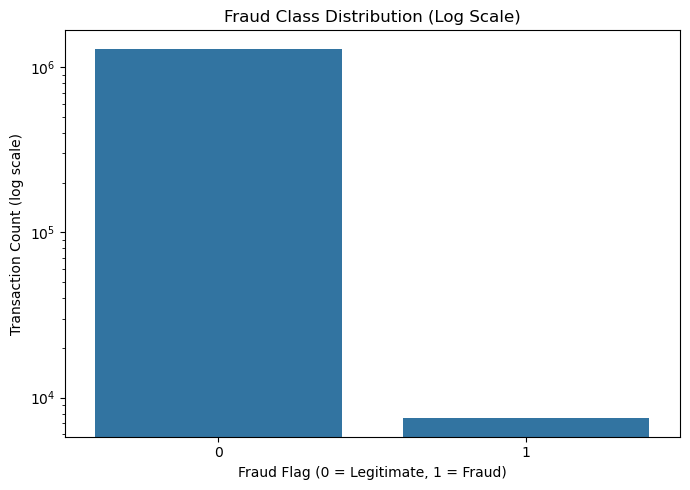

In [5]:
# Visualise the target imbalance without hiding the minority class.
plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x='is_fraud')
ax.set_yscale('log')
ax.set_title('Fraud Class Distribution (Log Scale)')
ax.set_xlabel('Fraud Flag (0 = Legitimate, 1 = Fraud)')
ax.set_ylabel('Transaction Count (log scale)')
plt.tight_layout()
plt.show()

**Finding — H1 supported.** At 0.5789% fraud, the imbalance is severe enough
that a linear-scale bar chart renders the fraud bar as visually
indistinguishable from zero; the log scale used above is necessary simply to
make the minority class visible at all, which is itself informal evidence of
how extreme the imbalance is. This confirms the modelling decisions already
planned in the project proposal: **accuracy is not a usable metric** (a
model predicting "not fraud" for every transaction would score 99.42%), and
**SMOTE must be fit on the training fold only**, after the train/test split,
to avoid leaking synthetic minority-class information into the evaluation
sets.

## 4. Transaction Amount Analysis

**Question:** Does transaction amount show a different distribution for
fraudulent and legitimate transactions?

Because `amt` is right-skewed (a small number of very large transactions
would otherwise dominate a raw-scale plot), both a raw summary-statistics
table and a log-transformed boxplot are used, and fraud rate is additionally
examined across fixed amount tiers to check whether the relationship is
linear or threshold-like.

### Hypothesis H2 — Transaction amount is associated with fraud risk
If the distributions or fraud rates differ materially by amount, transaction amount should be retained and potentially transformed/bucketed for the tree-based pipeline.

,count,mean,median,std,q1,q3,max
is_fraud,,,,,,,
0,1289169,67.67,47.28,154.01,9.61,82.54,28948.90
1,7506,531.32,396.50,390.56,245.66,900.88,1376.04


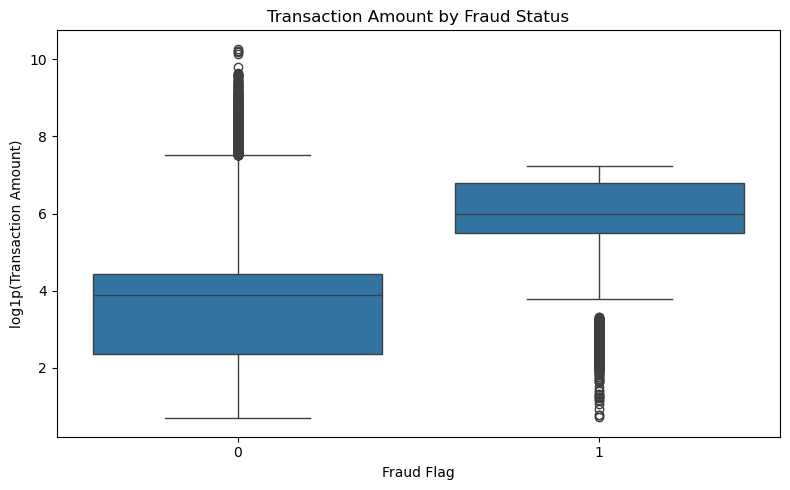

In [6]:
amount_summary = df.groupby('is_fraud')['amt'].agg(
    count='count', mean='mean', median='median', std='std',
    q1=lambda x: x.quantile(0.25), q3=lambda x: x.quantile(0.75), max='max'
).round(2)
display(amount_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y=np.log1p(df['amt']))
plt.title('Transaction Amount by Fraud Status')
plt.xlabel('Fraud Flag')
plt.ylabel('log1p(Transaction Amount)')
plt.tight_layout()
plt.show()

**Finding:** fraudulent transactions average `$531.32`  (median `$396.50`)
versus `$67.67`  (median `$47.28`) for legitimate ones — fraud transactions
run **nearly 8 times higher** on average. The spread (fraud std `$390.56` vs
legitimate std `$154.01`) is also much wider, consistent with fraud amounts
being less predictable/more varied than typical legitimate spending.

In [7]:
amount_bins = [0, 50, 100, 500, 1000, np.inf]
amount_labels = ['<50', '50-100', '100-500', '500-1k', '1k+']
tmp = df.assign(amount_tier=pd.cut(df['amt'], bins=amount_bins, labels=amount_labels, right=False))
amount_rates = tmp.groupby('amount_tier', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
amount_rates['fraud_rate_pct'] = amount_rates['mean'] * 100
display(amount_rates[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))

,count,fraud_count,fraud_rate_pct
amount_tier,,,
<50,672214,1607,0.2391
50-100,389514,45,0.0116
100-500,219316,2206,1.0059
500-1k,11694,2698,23.0717
1k+,3937,950,24.1300


**Finding — H2 strongly supported, with one anomaly worth noting.** Fraud
rate rises sharply and near-monotonically with amount: 0.24% (`<50`) →
1.01% (`100-500`) → 23.07% (`500-1k`) → 24.13% (`1k+`). Transactions over
`$500` are roughly **100 times** more likely to be fraudulent than
transactions under $50 — a very strong, clearly threshold-like signal well
suited to tree-based splitting.

**Error/anomaly note:** the `50-100` tier is the one exception to the
monotonic trend — its fraud rate (0.0116%) is actually **lower** than the
`<50` tier (0.2391%), not higher. This is a genuine dip, not a rounding
artifact (45 fraud cases out of 389,514 transactions is a large enough
sample to be reliable). One plausible explanation is that this range covers
routine, highly habitual spending (e.g. recurring subscriptions, regular
small purchases) that carries lower fraud risk than either very small
one-off purchases or larger transactions — this is a hypothesis for further
investigation, not a confirmed explanation, and is flagged here rather than
smoothed over so the tiered relationship is reported accurately.

## 5. Merchant Category Analysis

**Question:** Does fraud risk differ across merchant categories, and if so,
does the pattern reflect something more specific than "category" alone?

Fraud **rate**, not raw fraud count, is used so that large categories are
not automatically ranked as riskier simply because they contain more
transactions. All categories in this dataset have tens of thousands of
transactions, so — unlike the state-level analysis in Section 9 — small-
sample noise is not a concern here.

### Hypothesis H3 — Merchant category contains fraud-risk information
If fraud rates vary substantially across categories, category can be used as an input to the tree pipeline. For the final model, any target encoding must be fitted within the training data using out-of-fold logic; it should not be calculated on the full dataset before the train/test split.

,transactions,fraud_count,fraud_rate_pct
category,,,
shopping_net,97543,1713,1.7561
misc_net,63287,915,1.4458
grocery_pos,123638,1743,1.4098
shopping_pos,116672,843,0.7225
gas_transport,131659,618,0.4694
misc_pos,79655,250,0.3139
grocery_net,45452,134,0.2948
travel,40507,116,0.2864
entertainment,94014,233,0.2478


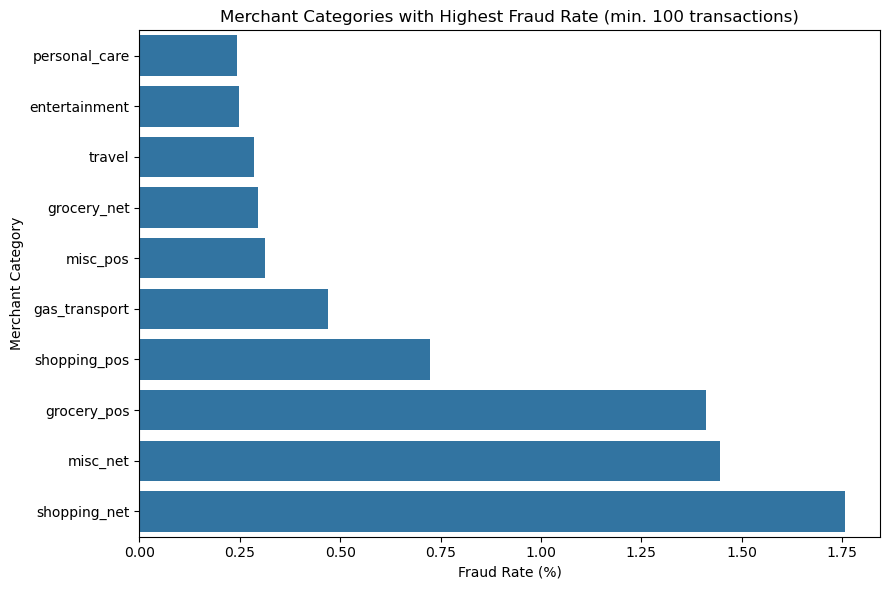

In [8]:
category_stats = df.groupby('category', observed=True)['is_fraud'].agg(
    transactions='count', fraud_count='sum', fraud_rate='mean'
).sort_values('fraud_rate', ascending=False)
category_stats['fraud_rate_pct'] = category_stats['fraud_rate'] * 100
display(category_stats[['transactions', 'fraud_count', 'fraud_rate_pct']].round(4))

plot_cat = category_stats[category_stats['transactions'] >= 100].head(10).sort_values('fraud_rate_pct')
plt.figure(figsize=(9, 6))
sns.barplot(data=plot_cat.reset_index(), x='fraud_rate_pct', y='category')
plt.title('Merchant Categories with Highest Fraud Rate (min. 100 transactions)')
plt.xlabel('Fraud Rate (%)')
plt.ylabel('Merchant Category')
plt.tight_layout()
plt.show()

**Finding — H3 supported.** Fraud rate ranges from **1.76%** (`shopping_net`)
down to **0.15%** (`health_fitness`) — an **11.3x spread** across categories,
all backed by large sample sizes (85,879 to 131,659 transactions per
category), so this is a reliable, not a small-sample, effect.

**A more specific pattern worth noting:** the risk difference is not simply
"category X is risky" — it also depends on **sales channel**, and the
direction of that effect reverses across categories. For `shopping`, the
online channel is riskier than in-person (`shopping_net` 1.76% vs
`shopping_pos` 0.72%, a 2.4x gap). For `grocery`, the opposite holds
(`grocery_pos` 1.41% vs `grocery_net` 0.29%, a 4.8x gap in the other
direction). This means category and channel likely interact rather than
acting independently — exactly the kind of interaction a tree-based model
can capture but a single linear "category risk score" would miss. This
strengthens the case for out-of-fold target encoding on the full `category`
field (which already implicitly captures the channel suffix) over any
coarser grouping.

## 6. Geospatial Behaviour

**Question:** Is the distance between the cardholder's home location and the
merchant's location associated with fraud?

The Haversine great-circle distance between `(lat, long)` and `(merch_lat,
merch_long)` is computed as an EDA feature to test this directly, rather
than relying on the raw coordinate pairs. This supports (or challenges) the
hypothesis for the later tree-based feature-engineering stage — the
coordinates themselves are not used as model inputs.

### Hypothesis H4 — Customer–merchant distance is a potential fraud indicator
If fraud rate increases in higher-distance bands, `distance_km` is a defensible candidate feature for XGBoost.

,count,median,mean,q1,q3,max
is_fraud,,,,,,
0,1289169,78.233,76.114,55.333,98.504,152.117
1,7506,77.932,76.268,55.633,98.391,144.522


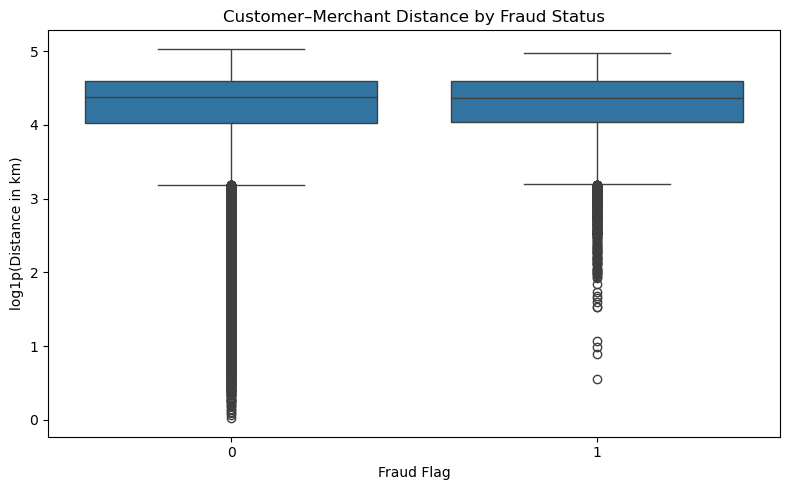

In [9]:
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371.0
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2)**2
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))

df['distance_km'] = haversine_distance(
    df['lat'], df['long'], df['merch_lat'], df['merch_long']
)

distance_summary = df.groupby('is_fraud')['distance_km'].agg(
    count='count', median='median', mean='mean',
    q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75), max='max'
).round(3)
display(distance_summary)

plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='is_fraud', y=np.log1p(df['distance_km']))
plt.title('Customer–Merchant Distance by Fraud Status')
plt.xlabel('Fraud Flag')
plt.ylabel('log1p(Distance in km)')
plt.tight_layout()
plt.show()

**Finding:** median distance is nearly identical for fraud (77.93 km) and
legitimate (78.23 km) transactions, and the interquartile ranges overlap
almost completely (fraud q1–q3: 55.63–98.39 km; legitimate: 55.33–98.50 km).
There is no visible separation between the two classes in this summary.

In [10]:
distance_bins = [0, 5, 10, 25, 50, 100, np.inf]
distance_labels = ['0-5 km', '5-10 km', '10-25 km', '25-50 km', '50-100 km', '100+ km']
tmp = df.assign(distance_band=pd.cut(df['distance_km'], bins=distance_bins, labels=distance_labels, right=False))
distance_rates = tmp.groupby('distance_band', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
distance_rates['fraud_rate_pct'] = distance_rates['mean'] * 100
display(distance_rates[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))


,count,fraud_count,fraud_rate_pct
distance_band,,,
0-5 km,2704,10,0.3698
5-10 km,7862,43,0.5469
10-25 km,55635,302,0.5428
25-50 km,198995,1128,0.5668
50-100 km,728628,4276,0.5869
100+ km,302851,1747,0.5769


**Finding — H4 not supported by the univariate evidence.** Fraud rate is
essentially flat across distance bands: 0.37% (`0-5 km`) to 0.59%
(`50-100 km`) — a **1.6x spread at most**, with no clear monotonic trend, well
short of the 11x–100x effects seen for category and amount. The lowest band
(`0-5 km`) also has the smallest sample (2,704 transactions), so some of that
particular figure's variation may be sampling noise rather than a genuine
effect.

**Revised interpretation:** this hypothesis, as originally framed ("larger
distance indicates higher fraud risk"), is **not supported**. `distance_km`
is retained as a candidate feature for the tree-based pipeline — not because
the univariate evidence justifies it, but because it may still contribute
through interactions with other variables that a single-variable band
analysis cannot detect (e.g. distance combined with amount, or with time of
day). This distinction — "retained for interaction testing" rather than
"validated as a standalone predictor" — is carried through explicitly to the
hypothesis-to-action summary in Section 11.

## 7. Population Context

**Question:** Does fraud risk differ across customer-location population
levels — i.e. do rural/small-town transactions carry different risk than
urban ones?

`city_pop` is heavily right-skewed, so quantile-based (rank) binning is used
rather than fixed-width bins, ensuring each population band contains a
comparable number of transactions (avoiding the sparsity issues that a
fixed-width bin would create at the high end of the distribution).

### Hypothesis H5 — Population context may provide additional fraud signal
Differences in fraud rates across population bands would justify testing `city_pop` and/or a carefully defined population-context feature in the tree model.

,count,median,mean,q1,q3
is_fraud,,,,,
0,1289169,2456.0,88775.23,743.0,20328.0
1,7506,2623.0,97276.76,746.5,21437.0


,count,fraud_count,fraud_rate_pct
population_band,,,
Very Low,259335,1545,0.5958
Low,259335,1413,0.5449
Medium,259335,1476,0.5691
High,259335,1557,0.6004
Very High,259335,1515,0.5842


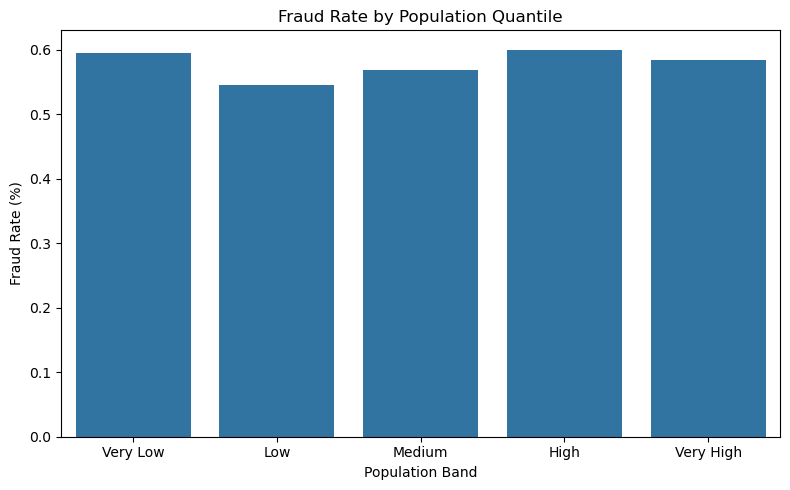

In [11]:
pop_summary = df.groupby('is_fraud')['city_pop'].agg(
    count='count', median='median', mean='mean',
    q1=lambda x: x.quantile(.25), q3=lambda x: x.quantile(.75)
).round(2)
display(pop_summary)

df['population_band'] = pd.qcut(
    df['city_pop'].rank(method='first'), q=5,
    labels=['Very Low', 'Low', 'Medium', 'High', 'Very High']
)
pop_rates = df.groupby('population_band', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
pop_rates['fraud_rate_pct'] = pop_rates['mean'] * 100
display(pop_rates[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))

plt.figure(figsize=(8, 5))
sns.barplot(data=pop_rates.reset_index(), x='population_band', y='fraud_rate_pct')
plt.title('Fraud Rate by Population Quantile')
plt.xlabel('Population Band')
plt.ylabel('Fraud Rate (%)')
plt.tight_layout()
plt.show()

**Finding — H5 not supported by the univariate evidence.** Median `city_pop`
is close between fraud (2,623) and legitimate (2,456) transactions, and the
quintile-banded fraud rate is essentially flat: 0.545% (`Low`) to 0.600%
(`High`) — only a **1.10x spread**, smaller even than the distance-band
effect in Section 6. There is no meaningful population-density signal in
this data on its own.

**Revised interpretation:** as with `distance_km`, `city_pop` is retained
only as a candidate for tree-based interaction testing, not as a validated
standalone predictor. Given how weak both geospatial signals are
individually, it may be worth testing whether they interact with each other
(e.g. large distance *and* low population together) rather than treating
either as an independent feature — a specific, testable follow-up for the
feature-engineering stage.

## 8. Temporal Fraud Patterns

**Question:** Does fraud risk vary by hour of day or day of week, and if
both show an effect, are they comparably strong?

Hour and day-of-week are examined separately (rather than combined into a
single timestamp feature) so that each effect's individual strength can be
assessed before deciding how — or whether — to combine them downstream.

### Hypothesis H6 — Fraud risk varies temporally
If certain hours or days have elevated fraud rates relative to the overall baseline, time-derived variables should be considered in later model development.

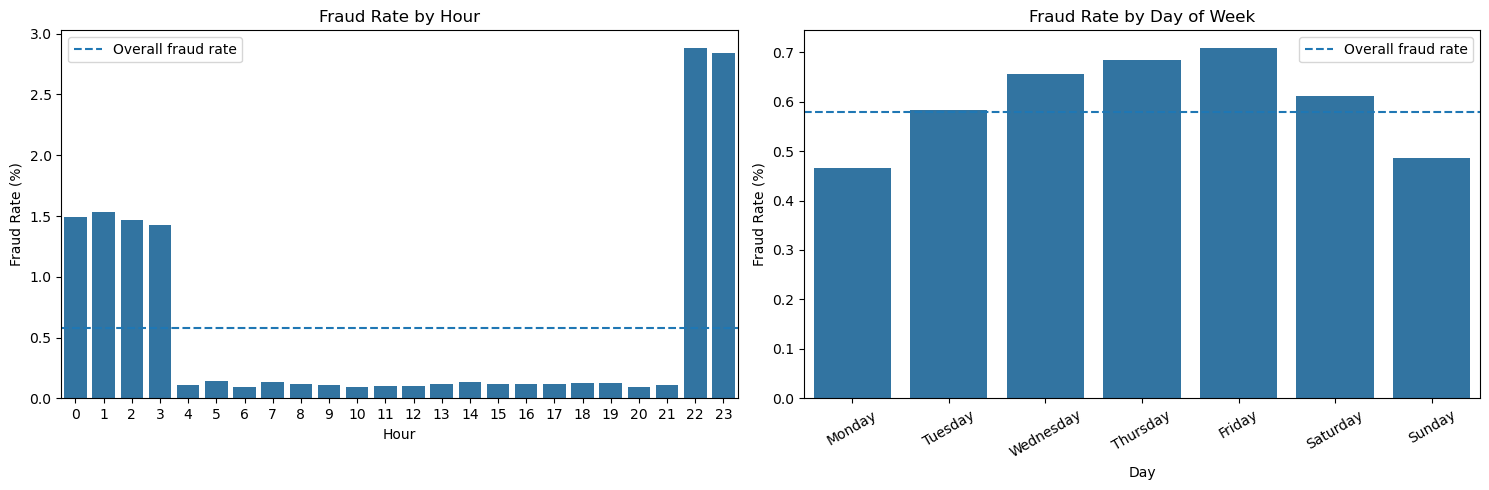

Highest hourly fraud-rate periods:


,count,sum,fraud_rate_pct
trans_hour,,,
22,66982,1931,2.8829
23,67104,1904,2.8374
1,42869,658,1.5349
0,42502,635,1.4940
2,42656,625,1.4652


Day-of-week fraud rates:


,count,sum,fraud_rate_pct
trans_day_of_week,,,
Monday,254282,1182,0.4648
Tuesday,160227,935,0.5835
Wednesday,131073,859,0.6554
Thursday,147285,1008,0.6844
Friday,152272,1079,0.7086
Saturday,200957,1227,0.6106
Sunday,250579,1216,0.4853


In [12]:
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])
df['trans_hour'] = df['trans_date_trans_time'].dt.hour
df['trans_day_of_week'] = df['trans_date_trans_time'].dt.day_name()
df['is_weekend'] = (df['trans_date_trans_time'].dt.dayofweek >= 5).astype(int)

hourly = df.groupby('trans_hour')['is_fraud'].agg(['count', 'sum', 'mean'])
hourly['fraud_rate_pct'] = hourly['mean'] * 100
daily = df.groupby('trans_day_of_week')['is_fraud'].agg(['count', 'sum', 'mean'])
daily['fraud_rate_pct'] = daily['mean'] * 100
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = daily.reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=hourly.reset_index(), x='trans_hour', y='fraud_rate_pct', ax=axes[0])
axes[0].axhline(df['is_fraud'].mean()*100, linestyle='--', label='Overall fraud rate')
axes[0].set_title('Fraud Rate by Hour')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].legend()

sns.barplot(data=daily.reset_index(), x='trans_day_of_week', y='fraud_rate_pct', ax=axes[1])
axes[1].axhline(df['is_fraud'].mean()*100, linestyle='--', label='Overall fraud rate')
axes[1].set_title('Fraud Rate by Day of Week')
axes[1].set_xlabel('Day')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend()

plt.tight_layout()
plt.show()

print('Highest hourly fraud-rate periods:')
display(hourly.sort_values('fraud_rate_pct', ascending=False).head(5)[['count','sum','fraud_rate_pct']].round(4))
        
print('Day-of-week fraud rates:')
display(daily[['count','sum','fraud_rate_pct']].round(4))

**Finding — H6 supported, but the two temporal effects are not equally
strong.** Hour-of-day shows a large effect: fraud rate peaks at **2.88%**
(22:00) and **2.84%** (23:00) — roughly **5 times** the overall 0.58%
baseline — with elevated rates continuing through the early hours (00:00–
02:00, 1.49%–1.53%). Day-of-week shows a much milder effect: Friday is
highest at 0.71%, Monday lowest at 0.46% — only a **1.5x spread**, an order
of magnitude weaker than the hour-of-day pattern.

**Implication for feature engineering:** `trans_hour` is a strong, high-
priority candidate feature. Day-of-week is a real but comparatively weak
signal — worth retaining (it costs nothing to include), but it should not be
expected to carry as much predictive weight as hour, and `is_weekend` as a
simplification may lose more information than it's worth given the actual
pattern peaks on a weekday (Friday), not the weekend.

## 9. Demographic and Regional Patterns — Fairness Baseline

**Question:** Do outcome rates (fraud flags) differ across cardholder age,
gender, and state, and if so, by how much?

These analyses are **not used to claim that a demographic attribute causes
fraud** — none of these attributes plausibly cause fraudulent activity, and
none are proposed as model input features here. Instead, this section
establishes a quantified **baseline of outcome differences** that the M-08
Bias Detection & Fairness Blueprint uses to define monitoring brackets and
compare against the trained model's actual predictions (Demographic Parity
and Equalized Odds are computed against model outputs in the dedicated
fairness notebook, not against raw data here — this section only documents
what the underlying data itself looks like before any model is involved). A
minimum sample size of 100 transactions is applied to the state-level
breakdown specifically, since state has far more categories and much
smaller per-group counts than age or gender, making it the bracket most
susceptible to small-sample distortion.

In [13]:
import os
import numpy as np
import pandas as pd
from IPython.display import display

print("\n--- AI Governance: Computing & Exporting Fairness Baselines ---")

# 1. Calculate 'age' from 'dob' and 'trans_date_trans_time'
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'], errors='coerce')

df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year
before_birthday = (
    (df['trans_date_trans_time'].dt.month < df['dob'].dt.month) | 
    ((df['trans_date_trans_time'].dt.month == df['dob'].dt.month) & 
     (df['trans_date_trans_time'].dt.day < df['dob'].dt.day))
)
df['age'] -= before_birthday.fillna(0).astype(int)

# 2. Age Bracket Fraud Rate
age_bins = [0, 25, 35, 45, 55, 65, 120]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['age_bracket'] = pd.cut(df['age'], bins=age_bins, labels=age_labels, right=False)

age_stats = df.groupby('age_bracket', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
age_stats['fraud_rate_pct'] = age_stats['mean'] * 100
print("\nFraud Rate by Age Bracket (%):")
display(age_stats[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))

# 3. Gender Fraud Rate
gender_stats = df.groupby('gender', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
gender_stats['fraud_rate_pct'] = gender_stats['mean'] * 100
print("\nFraud Rate by Gender (%):")
display(gender_stats[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))

# 4. Geographic Fraud Rate (Top 10 States)
state_counts = df['state'].value_counts()
valid_states = state_counts[state_counts >= 100].index
df_valid_states = df[df['state'].isin(valid_states)]

state_stats = df_valid_states.groupby('state', observed=True)['is_fraud'].agg(['count', 'sum', 'mean'])
state_stats['fraud_rate_pct'] = state_stats['mean'] * 100
state_stats = state_stats.sort_values('fraud_rate_pct', ascending=False)

print("\nHighest fraud-rate states with at least 100 transactions:")
display(state_stats.head(10)[['count', 'sum', 'fraud_rate_pct']].rename(columns={'sum':'fraud_count'}).round(4))

age_export = (
    age_stats[['count', 'sum', 'fraud_rate_pct']]
    .reset_index()
    .rename(columns={'age_bracket':'Cohort','count':'Transaction_Count','sum':'Fraud_Count','fraud_rate_pct':'Fraud_Rate_Percent'})
)
age_export['Cohort'] = 'Age: ' + age_export['Cohort'].astype(str)

gender_export = (
    gender_stats[['count', 'sum', 'fraud_rate_pct']]
    .reset_index()
    .rename(columns={'gender':'Cohort','count':'Transaction_Count','sum':'Fraud_Count','fraud_rate_pct':'Fraud_Rate_Percent'})
)
gender_export['Cohort'] = 'Gender: ' + gender_export['Cohort'].astype(str)

state_export = (
    state_stats[['count', 'sum', 'fraud_rate_pct']]
    .reset_index()
    .rename(columns={'state':'Cohort','count':'Transaction_Count','sum':'Fraud_Count','fraud_rate_pct':'Fraud_Rate_Percent'})
)
state_export['Cohort'] = 'State: ' + state_export['Cohort'].astype(str)

fairness_df = pd.concat([age_export, gender_export, state_export], ignore_index=True)

LOCAL_FAIRNESS_PATH.parent.mkdir(parents=True, exist_ok=True)
fairness_df.to_csv(LOCAL_FAIRNESS_PATH, index=False)
S3_FAIRNESS_URI = s3_join(S3_EDA_OUTPUT_URI, FAIRNESS_BASELINE_FILENAME)
upload_local_to_s3(LOCAL_FAIRNESS_PATH, S3_FAIRNESS_URI)

print(f"\n✓ Fairness baseline saved locally: {LOCAL_FAIRNESS_PATH}")
print(f"✓ Fairness baseline S3 URI: {S3_FAIRNESS_URI}")
display(fairness_df.round(4))

df = df.drop(columns=['age_bracket'])



--- AI Governance: Computing & Exporting Fairness Baselines ---

Fraud Rate by Age Bracket (%):


,count,fraud_count,fraud_rate_pct
age_bracket,,,
<25,121663,764,0.6280
25-34,287689,1391,0.4835
35-44,272943,1163,0.4261
45-54,256600,1491,0.5811
55-64,164081,1259,0.7673
65+,193699,1438,0.7424



Fraud Rate by Gender (%):


,count,fraud_count,fraud_rate_pct
gender,,,
F,709863,3735,0.5262
M,586812,3771,0.6426



Highest fraud-rate states with at least 100 transactions:


,count,fraud_count,fraud_rate_pct
state,,,
RI,550,15,2.7273
AK,2120,36,1.6981
NV,5607,47,0.8382
CO,13880,113,0.8141
OR,18597,149,0.8012
TN,17554,140,0.7975
NE,24168,180,0.7448
ME,16505,119,0.7210
NH,8278,59,0.7127


✓ Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/eda/fairness_baselines.csv

✓ Fairness baseline saved locally: data/eda/fairness_baselines.csv
✓ Fairness baseline S3 URI: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/eda/fairness_baselines.csv


,Cohort,Transaction_Count,Fraud_Count,Fraud_Rate_Percent
0,Age: <25,121663,764,0.6280
1,Age: 25-34,287689,1391,0.4835
2,Age: 35-44,272943,1163,0.4261
3,Age: 45-54,256600,1491,0.5811
4,Age: 55-64,164081,1259,0.7673
5,Age: 65+,193699,1438,0.7424
6,Gender: F,709863,3735,0.5262
7,Gender: M,586812,3771,0.6426
8,State: RI,550,15,2.7273
9,State: AK,2120,36,1.6981


**Finding.** Three outcome-rate gaps are present in the raw data, all modest
in size relative to the amount and category effects found earlier:

- **Age:** a mild U-shape — the youngest (`<25`, 0.63%) and older brackets
  (`55-64`, 0.77%; `65+`, 0.74%) show higher fraud rates than the `35-44`
  trough (0.43%), a **1.8x spread** between the highest and lowest brackets.
- **Gender:** Male 0.64% vs Female 0.53% — a **1.22x** gap.
- **State:** Rhode Island is highest at 2.73% (n=550, above the minimum
  threshold but still notably smaller than most other states' sample
  sizes — worth some added caution relative to states with tens of
  thousands of transactions), followed by a long tail of states clustered
  well under 1%.

None of these gaps approach the strength of the amount or category effects,
but all three are large enough to warrant formal monitoring brackets under
M-08, since even modest outcome-rate differences can compound into
meaningful disparities once translated into model *predictions* rather than
raw *labels* — which is precisely what the Demographic Parity / Equalized
Odds computation in the dedicated fairness notebook is designed to test.

## 10. Multivariate Signal Check

A correlation matrix is useful as a **screening tool**, but correlation
alone does not establish predictive power — it only captures *linear*
relationships. Tree-based models can capture non-linear relationships and
interactions that simple Pearson correlation misses. Rather than stating
this as an abstract caveat, the comparison below uses this notebook's own
`trans_hour` finding as a direct, concrete demonstration of the gap between
linear correlation and actual predictive signal.

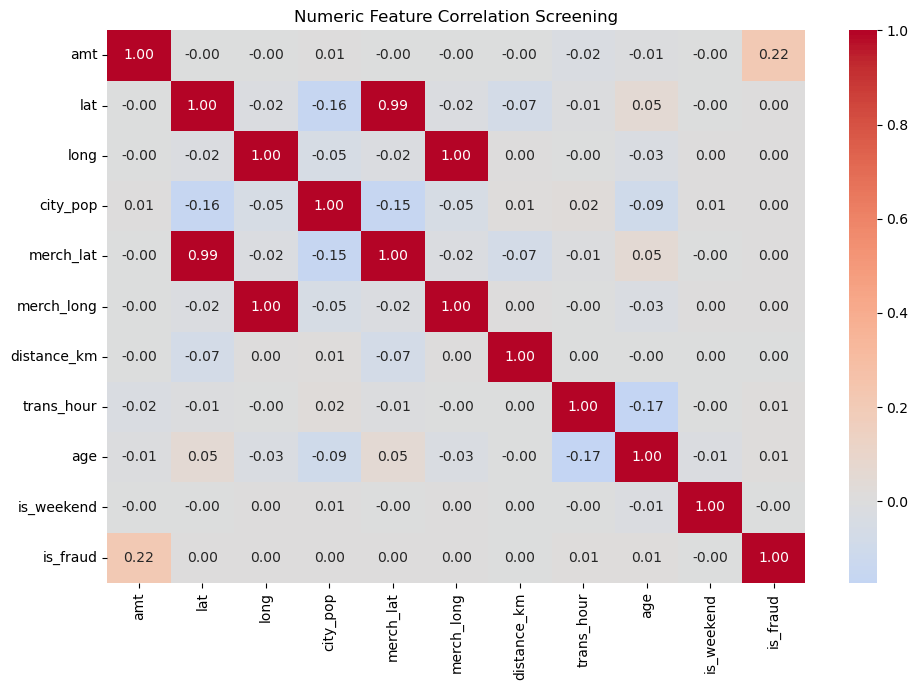

Correlation with is_fraud:


,correlation
is_fraud,1.000000
amt,0.219404
trans_hour,0.013799
age,0.012248
city_pop,0.002136
lat,0.001894
merch_lat,0.001741
merch_long,0.001721
long,0.001721
distance_km,0.000403


In [14]:
numeric_candidates = [
    c for c in ['amt','lat','long','city_pop','merch_lat','merch_long',
                'distance_km','trans_hour','age','is_weekend','is_fraud']
    if c in df.columns
]
corr = df[numeric_candidates].corr(numeric_only=True)

plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Numeric Feature Correlation Screening')
plt.tight_layout()
plt.show()

print('Correlation with is_fraud:')
display(corr['is_fraud'].sort_values(ascending=False).to_frame('correlation'))

**Finding.** `amt` is the only feature with a correlation to `is_fraud`
that would conventionally be called meaningful (**0.219**). Every other
feature is below 0.02 — including `trans_hour` (0.014), `age` (0.012),
`city_pop` (0.002), and `distance_km` (0.0004).

**This is exactly the contrast the section intro predicts, and it plays out
two different ways depending on the feature:**

- **`trans_hour` is the case where correlation understates the true
  signal.** Its linear correlation (0.014) looks negligible, yet Section 8
  found a genuine ~5x fraud-rate lift at 22:00–23:00. The relationship is
  real but *non-linear* (a late-night spike, not a steady linear trend
  across 24 hours) — a Pearson correlation cannot see this shape, but a
  tree split at "hour ≥ 22" can.
- **`distance_km` and `city_pop` are the case where correlation and the
  bucketed analysis agree.** Both showed near-flat fraud rates across bands
  in Sections 6 and 7, *and* both show near-zero correlation here. Two
  independent methods reaching the same conclusion is stronger evidence
  that these two signals are genuinely weak, not just linearly
  uncorrelated.

This distinction — weak-and-confirmed-weak vs. weak-correlation-but-real-
signal — is what determines how each feature is treated in Section 11.

## 11. Independent Hypothesis → Feature Engineering Decisions

The EDA closes by explicitly connecting each hypothesis to a graded judgement
on the strength of its supporting evidence, and a specific next-stage action
— rather than treating every hypothesis as equally validated. Three tiers are
used: **Strong** (large, consistent effect — e.g. amount, category, hour),
**Moderate** (real but comparatively small effect — e.g. day-of-week, age,
gender, state), and **Weak/Not Supported** (no meaningful univariate
separation — e.g. distance, population), each carrying a different
implication for how the feature is used downstream.

In [15]:
hypothesis_matrix = pd.DataFrame([
    ['H1', 'Fraud is highly imbalanced.', 'Strong', 'Use stratified splitting; apply SMOTE to training data only.', 'XGBoost + SMOTE'],
    ['H2', 'Transaction amount differs sharply by fraud status (~100x lift above $500).', 'Strong', 'Retain amt; the amount-tier lift justifies tree-based threshold splits.', 'Tree feature pipeline'],
    ['H3', 'Fraud rate varies by merchant category and channel (11.3x spread).', 'Strong', 'Fit target encoding within training folds only (out-of-fold).', 'Category risk encoding'],
    ['H4', 'Customer–merchant distance shows no meaningful univariate separation (1.6x spread, flat).', 'Weak / Not Supported', 'Retain only as a candidate for tree-based interaction effects, not a standalone predictor.', 'distance_km (interaction candidate)'],
    ['H5', 'Population context shows no meaningful univariate separation (1.1x spread, flat).', 'Weak / Not Supported', 'Retain only as a candidate for tree-based interaction effects, not a standalone predictor.', 'city_pop (interaction candidate)'],
    ['H6', 'Fraud risk varies strongly by hour (~5x at night) and mildly by day-of-week (1.5x).', 'Strong (hour) / Moderate (day)', 'Prioritise trans_hour; retain day-of-week as a secondary signal.', 'Temporal features'],
    ['H7', 'Outcome rates differ modestly by age (1.8x), gender (1.2x) and state (up to 2.7%).', 'Moderate', 'Use as fairness monitoring brackets under M-08; do not infer causality.', 'Fairness evaluation'],
], columns=['ID', 'EDA Hypothesis', 'Evidence Strength', 'Implication', 'Next-stage Action'])

display(hypothesis_matrix)

,ID,EDA Hypothesis,Evidence Strength,Implication,Next-stage Action
0,H1,Fraud is highly imbalanced.,Strong,Use stratified splitting; apply SMOTE to train...,XGBoost + SMOTE
1,H2,Transaction amount differs sharply by fraud st...,Strong,Retain amt; the amount-tier lift justifies tre...,Tree feature pipeline
2,H3,Fraud rate varies by merchant category and cha...,Strong,Fit target encoding within training folds only...,Category risk encoding
3,H4,Customer–merchant distance shows no meaningful...,Weak / Not Supported,Retain only as a candidate for tree-based inte...,distance_km (interaction candidate)
4,H5,Population context shows no meaningful univari...,Weak / Not Supported,Retain only as a candidate for tree-based inte...,city_pop (interaction candidate)
5,H6,Fraud risk varies strongly by hour (~5x at nig...,Strong (hour) / Moderate (day),Prioritise trans_hour; retain day-of-week as a...,Temporal features
6,H7,"Outcome rates differ modestly by age (1.8x), g...",Moderate,Use as fairness monitoring brackets under M-08...,Fairness evaluation


In [16]:
# ============================================================
# Export EDA Feature Candidates — Source of Truth for Feature Engineering
# ============================================================
# This JSON is the hand-off artifact. Feature Engineering reads this
# file instead of hard-coding which EDA findings are considered selected.

EDA_FEATURE_CONFIG = {
    "schema_version": "1.0",
    "dataset_filename": DATA_FILENAME,
    "target": "is_fraud",
    "selected_features": [
        "amt", "amt_log", "category_te", "distance_km", "distance_log",
        "city_pop", "trans_hour", "day_of_week", "is_weekend",
        "age", "gender_binary"
    ],
    "target_dependent_features": ["category_te"],
    "feature_definitions": {
        "amt": {"source": "amt", "operation": "identity"},
        "amt_log": {"source": "amt", "operation": "log1p"},
        "category_te": {"source": "category", "operation": "target_encoding_oof"},
        "distance_km": {"source": ["lat", "long", "merch_lat", "merch_long"], "operation": "haversine_km"},
        "distance_log": {"source": "distance_km", "operation": "log1p"},
        "city_pop": {"source": "city_pop", "operation": "identity"},
        "trans_hour": {"source": "trans_date_trans_time", "operation": "hour"},
        "day_of_week": {"source": "trans_date_trans_time", "operation": "dayofweek"},
        "is_weekend": {"source": "trans_date_trans_time", "operation": "weekend"},
        "age": {"source": ["dob", "trans_date_trans_time"], "operation": "age_at_transaction"},
        "gender_binary": {"source": "gender", "operation": "binary_mapping"}
    },
    "notes": "Selected feature candidates are defined by EDA; target-dependent encoding is fitted only after the modelling split."
}

with open(LOCAL_EDA_CONFIG_PATH, "w", encoding="utf-8") as f:
    json.dump(EDA_FEATURE_CONFIG, f, indent=2)

S3_EDA_CONFIG_URI = s3_join(S3_EDA_OUTPUT_URI, EDA_FEATURE_CONFIG_FILENAME)
upload_local_to_s3(LOCAL_EDA_CONFIG_PATH, S3_EDA_CONFIG_URI)
mlflow.log_artifact(str(LOCAL_EDA_CONFIG_PATH), artifact_path="eda_outputs")

print("\n✓ EDA feature configuration exported")
print("Local:", LOCAL_EDA_CONFIG_PATH)
print("S3:", S3_EDA_CONFIG_URI)
print("Selected features:", EDA_FEATURE_CONFIG["selected_features"])


✓ Saved to S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/eda/eda_feature_candidates.json

✓ EDA feature configuration exported
Local: data/eda/eda_feature_candidates.json
S3: s3://nyp-26s1-iti113/iti113/team04/data/credit-card-fraud-detection/processed/eda/eda_feature_candidates.json
Selected features: ['amt', 'amt_log', 'category_te', 'distance_km', 'distance_log', 'city_pop', 'trans_hour', 'day_of_week', 'is_weekend', 'age', 'gender_binary']


## 12. Data Leakage and Modelling Boundary

**Why this matters specifically for this project:** fitting SMOTE, target
encoding, feature selection, or scaling on the full dataset before splitting
would let information from the evaluation sets leak into the training
process. In a severely imbalanced problem like this one (0.58% fraud), that
kind of leakage tends to produce validation metrics that look strong but
collapse on genuinely unseen data — a risk this project has specifically
guarded against by keeping this notebook EDA-only and deferring all fitting
steps to the modelling notebooks.

### Do **not** do these operations in the EDA notebook before train/test splitting:
- SMOTE on the full dataset
- Target encoding using all rows
- Selecting features using the test set
- Fitting scalers/imputers on the test set
- Reporting model performance from the same data used to construct the feature

### Important merchant-name check
Do **not** automatically remove a `fraud_` prefix from `merchant` unless you
have confirmed that the prefix is an artefact of the dataset and not a
meaningful field. If it directly identifies the target, treat it as target
leakage and document the decision rather than silently modifying it.

For the later XGBoost pipeline: perform the train/validation/test split
first, then fit preprocessing and out-of-fold target encoding on the
training partition only.

In [17]:
# MLOps Safety Catch: End any dangling active runs from previous crashes
if mlflow.active_run():
    mlflow.end_run()

RUN_NAME = f"{STUDENT_ID}_EDA"

with mlflow.start_run(run_name=RUN_NAME) as run:

    # Log high-level dataset metrics
    mlflow.log_param("dataset_filename", DATA_FILENAME)
    mlflow.log_param("dataset_source", DATA_S3_URI)
    mlflow.log_metric("transaction_count", int(len(df)))
    mlflow.log_metric("fraud_count", int(df["is_fraud"].sum()))
    mlflow.log_metric("fraud_rate", float(df["is_fraud"].mean()))
    mlflow.log_param("selected_feature_count", len(EDA_FEATURE_CONFIG["selected_features"]))

    # Log the EDA Feature Configuration JSON and Fairness CSV as artifacts
    mlflow.log_artifact(str(LOCAL_EDA_CONFIG_PATH), artifact_path="eda_outputs")
    
    print(f"✓ EDA MLflow run completed.")
    print(f"Run name: {RUN_NAME}")
    print(f"Run ID: {run.info.run_id}")

🏃 View run youthful-fish-296 at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4/runs/52b17b5878f947f88ac0d500dec0d29d
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4
✓ EDA MLflow run completed.
Run name: S402_EDA
Run ID: 4146472cefe44a9c9eae1c94d34d3904
🏃 View run S402_EDA at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4/runs/4146472cefe44a9c9eae1c94d34d3904
🧪 View experiment at: https://mlflow.sagemaker.ap-southeast-1.app.aws/#/experiments/4


## 13. Individual Milestone Contribution — Jianhui

**Completed / evidence to attach:**
- [x] Dataset and data-quality profiling
- [x] Fraud-class imbalance analysis
- [x] Transaction-amount analysis
- [x] Merchant-category fraud-rate analysis
- [x] Haversine distance analysis
- [x] Population-context analysis
- [x] Temporal fraud analysis
- [x] Demographic/regional fairness baseline
- [x] Independent hypothesis matrix
- [x] Proposed tree-based feature-engineering decisions

### Summary of findings
Two features carry strong, well-supported signal on their own: **transaction
amount** (near-100x fraud-rate lift above $500) and **merchant category**
(11.3x spread, with an online-vs-in-person channel effect that reverses
direction between categories). **Hour-of-day** is similarly strong (~5x lift
at night) but only visible through bucketed analysis — its linear
correlation is misleadingly close to zero, the clearest demonstration in
this notebook of why correlation alone cannot screen features for a tree-
based model. **Day-of-week, age, gender,** and **state** show real but
modest effects (1.2x–1.8x), appropriate as fairness-monitoring brackets
rather than primary predictive features. **Distance and population density
showed no meaningful univariate signal** — both are retained only as
candidates for tree-based interaction testing, not validated as standalone
predictors, a distinction carried through explicitly to Section 11 rather
than overstated.

**Next milestone:** Feature Engineering loads `eda_feature_candidates.json`
from S3 (with local fallback) and applies the EDA-selected candidates
without hard-coding the EDA selection.